# Análise exploratória
## Ativo - ITUB4

In [1]:
# Importanto bibliotecas necessárias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [14]:
# Definindo o caminho para os dados
PATH = "/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/itub4_processed.csv"

In [16]:
# Importando o dataset
df = pd.read_csv(PATH, index_col="Date", parse_dates=True)

df.head()

,Close,High,Low,Open,Volume,EMA_60
Date,,,,,,
2021-05-03,17.981256,18.168159,17.775020,17.852358,46978032,17.981256
2021-05-04,17.214302,18.271264,17.175634,18.110143,89509379,17.956110
2021-05-05,17.704119,17.820127,17.091854,17.336761,56856659,17.947848
2021-05-06,17.594553,17.800790,17.459210,17.633222,27016611,17.936265
2021-05-07,17.807234,17.852348,17.555883,17.665447,30255405,17.932034


## Análise 01 - Série Histórica de preços e volumes

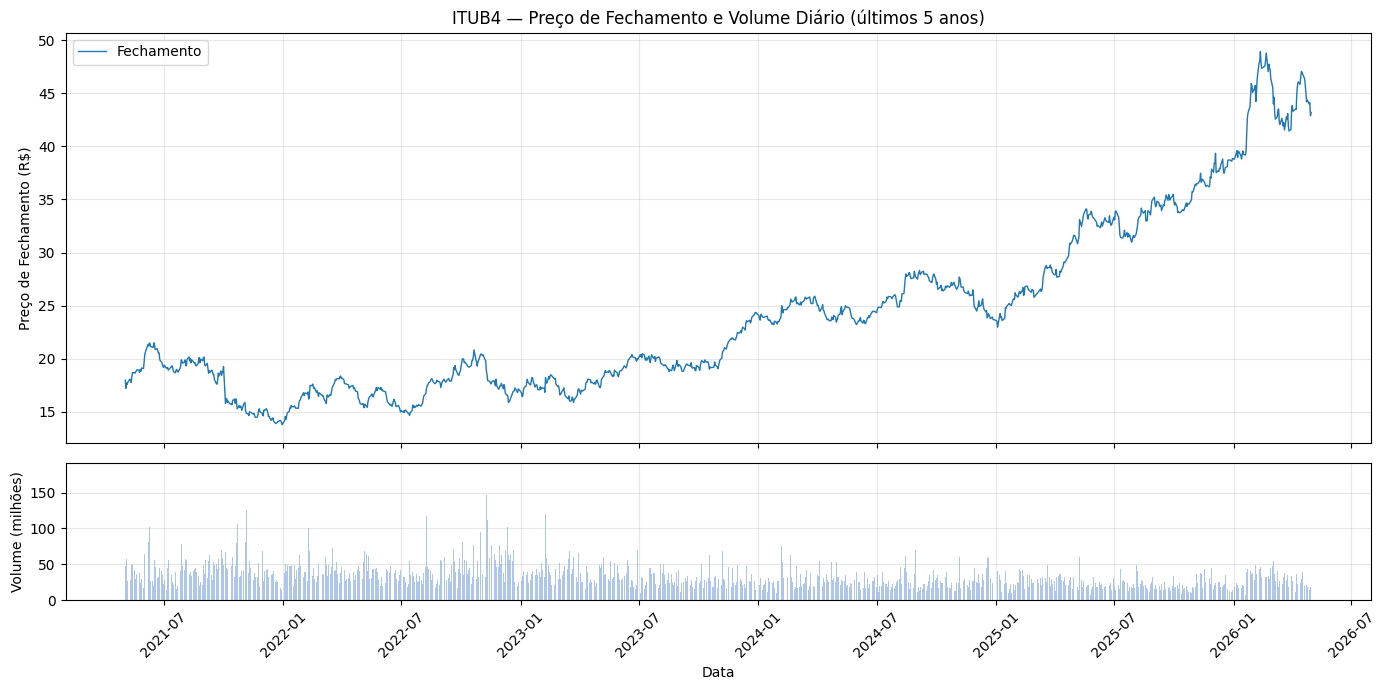

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(df.index, df["Close"], color="#1f77b4", linewidth=1.0, label="Fechamento")
ax1.set_ylabel("Preço de Fechamento (R$)")
ax1.set_title("ITUB4 — Preço de Fechamento e Volume Diário (últimos 5 anos)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

ax2.bar(df.index, df["Volume"] / 1e6, color="#aec7e8", width=1.0)
ax2.set_ylabel("Volume (milhões)")
ax2.set_xlabel("Data")
ax2.grid(alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/01_preco_volume.png", dpi=300, bbox_inches="tight")
plt.show()

# Análise 02 - Retornos diários logarítmicos

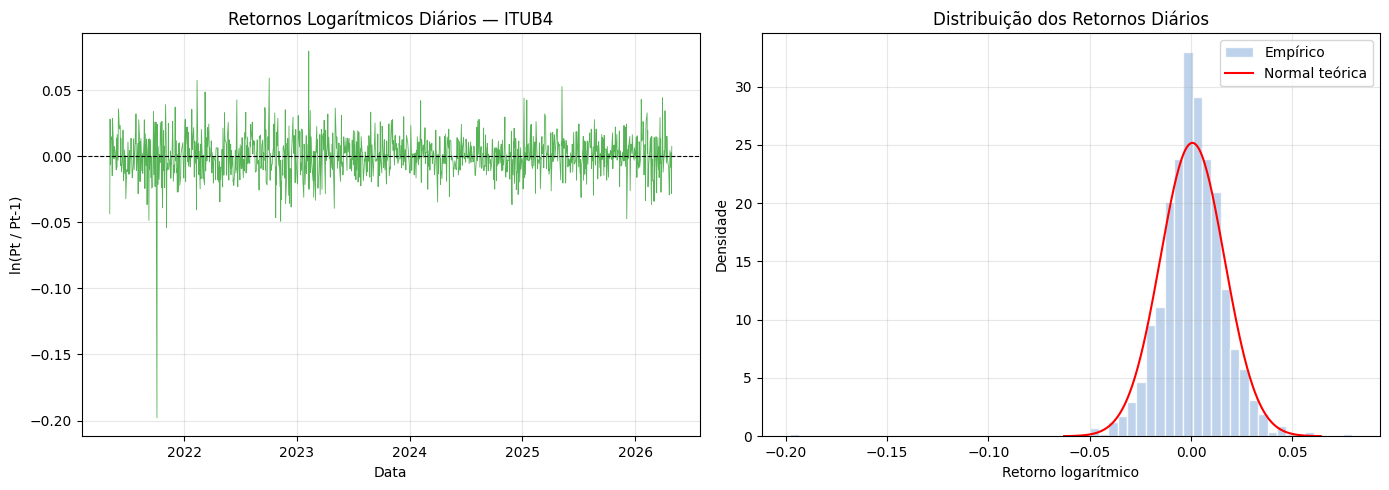

count    1246.000000
mean        0.000703
std         0.015843
min        -0.198016
25%        -0.008130
50%         0.000607
75%         0.010033
max         0.079447
Name: log_return, dtype: float64
Curtose: 20.3120
Assimetria: -1.4477


In [19]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Série temporal dos retornos
axes[0].plot(df.index, df["log_return"], color="#2ca02c", linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Retornos Logarítmicos Diários — ITUB4")
axes[0].set_ylabel("ln(Pt / Pt-1)")
axes[0].set_xlabel("Data")
axes[0].grid(alpha=0.3)

# Histograma com curva normal sobreposta
from scipy.stats import norm

mu, sigma = df["log_return"].dropna().mean(), df["log_return"].dropna().std()
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
axes[1].hist(df["log_return"].dropna(), bins=60, density=True,
             color="#aec7e8", edgecolor="white", alpha=0.8, label="Empírico")
axes[1].plot(x, norm.pdf(x, mu, sigma), "r-", linewidth=1.5, label="Normal teórica")
axes[1].set_title("Distribuição dos Retornos Diários")
axes[1].set_xlabel("Retorno logarítmico")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/02_retornos_diarios.png", dpi=300, bbox_inches="tight")
plt.show()

# Estatísticas resumidas
print(df["log_return"].describe())
print(f"Curtose: {df['log_return'].dropna().kurt():.4f}")
print(f"Assimetria: {df['log_return'].dropna().skew():.4f}")

# Análise 03 - Médias móveis sobrepostas ao preço 

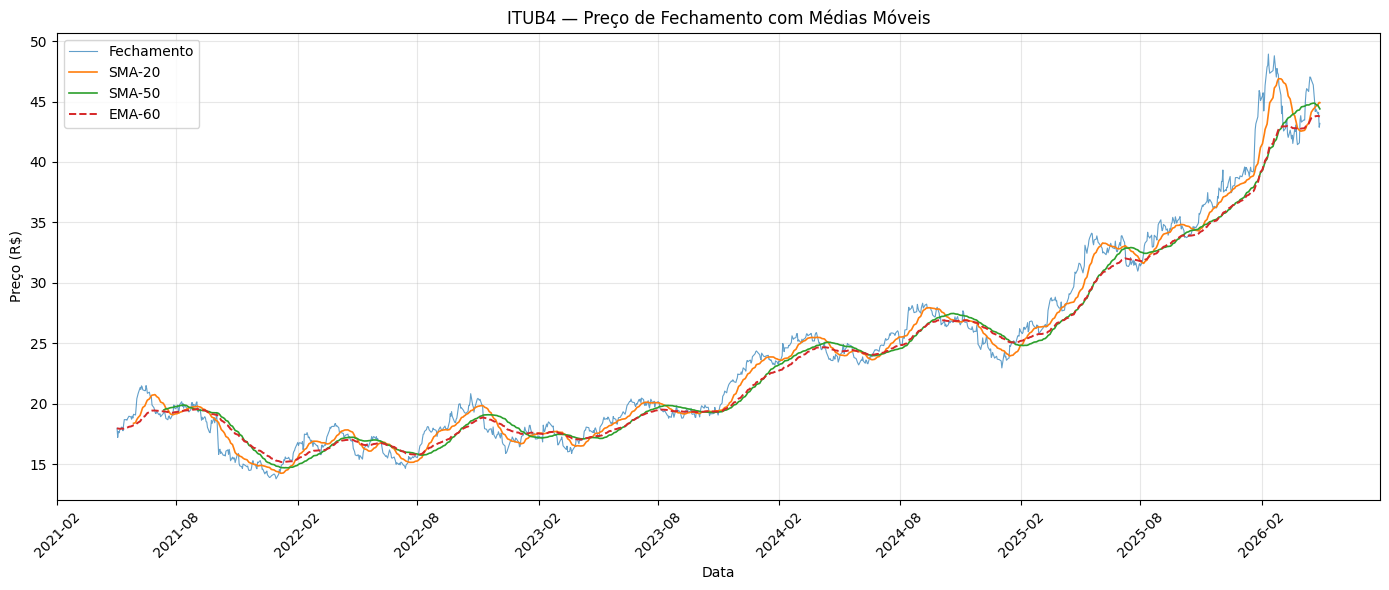

In [20]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"],  color="#1f77b4", linewidth=0.8, alpha=0.7, label="Fechamento")
ax.plot(df.index, df["SMA_20"], color="#ff7f0e", linewidth=1.2, label="SMA-20")
ax.plot(df.index, df["SMA_50"], color="#2ca02c", linewidth=1.2, label="SMA-50")
ax.plot(df.index, df["EMA_60"], color="#d62728", linewidth=1.4, linestyle="--", label="EMA-60")

ax.set_title("ITUB4 — Preço de Fechamento com Médias Móveis")
ax.set_ylabel("Preço (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/03_medias_moveis.png", dpi=300, bbox_inches="tight")
plt.show()

# Análise 04 - Mapa de calor de correlções ( Pearson )

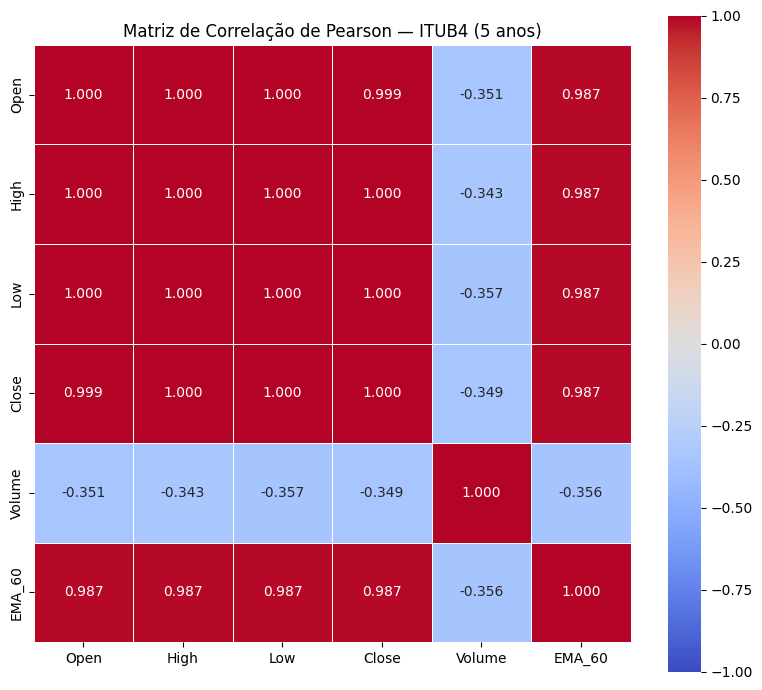

            Open      High       Low     Close    Volume    EMA_60
Open    1.000000  0.999630  0.999656  0.999201 -0.350696  0.987348
High    0.999630  1.000000  0.999657  0.999701 -0.343185  0.987092
Low     0.999656  0.999657  1.000000  0.999679 -0.356645  0.987204
Close   0.999201  0.999701  0.999679  1.000000 -0.348991  0.986612
Volume -0.350696 -0.343185 -0.356645 -0.348991  1.000000 -0.355578
EMA_60  0.987348  0.987092  0.987204  0.986612 -0.355578  1.000000


In [22]:
features = ["Open", "High", "Low", "Close", "Volume", "EMA_60"]
corr_matrix = df[features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # mostra triângulo inferior

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlação de Pearson — ITUB4 (5 anos)")
plt.tight_layout()
#plt.savefig("data/figures/04_correlacao_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix)

# Análise 05 - Identificação visual de períodos atípicos

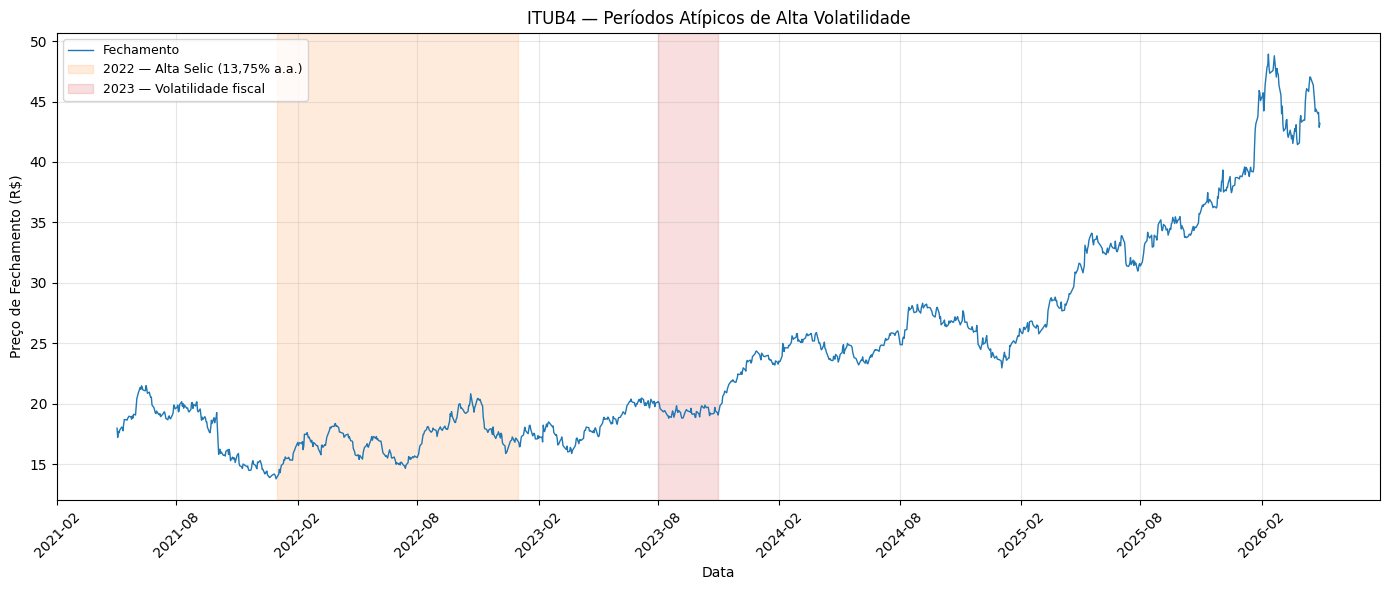

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"], color="#1f77b4", linewidth=1.0, label="Fechamento")

# Definir períodos atípicos dentro do recorte de 5 anos
# (ajuste as datas conforme o período real do download)
atypical_periods = [
    ("2022-01-01", "2022-12-31", "#ff7f0e", "2022 — Alta Selic (13,75% a.a.)"),
    ("2023-08-01", "2023-10-31", "#d62728", "2023 — Volatilidade fiscal"),
]

for start, end, color, label in atypical_periods:
    # Verificar se o período está dentro do range do df
    start_dt = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)
    if start_dt >= df.index[0] and end_dt <= df.index[-1]:
        ax.axvspan(start_dt, end_dt, alpha=0.15, color=color, label=label)

ax.set_title("ITUB4 — Períodos Atípicos de Alta Volatilidade")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/05_periodos_atipicos.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
summary = df[["Open", "High", "Low", "Close", "Volume", "EMA_60"]].describe()
print(summary.to_string())

              Open         High          Low        Close        Volume       EMA_60
count  1247.000000  1247.000000  1247.000000  1247.000000  1.247000e+03  1247.000000
mean     23.961687    24.215549    23.715908    23.966907  3.288489e+07    23.357064
std       7.992016     8.055403     7.929616     7.995119  1.622914e+07     7.249738
min      13.945731    14.026130    13.762846    13.789177  6.695412e+06    15.169766
25%      17.819681    18.013663    17.615355    17.810044  2.198434e+07    17.605275
50%      20.926794    21.204540    20.720120    20.959099  2.946514e+07    19.521267
75%      27.451340    27.757023    27.138300    27.530972  4.029414e+07    26.771031
max      48.608865    49.223288    48.162912    48.925987  1.820390e+08    43.810181
